In [22]:
# load the dataset of top U.S. colleges from 2022
import pandas as pd

df = pd.read_csv('top_colleges_2022.csv')

In [23]:
# select the numeric features to use for clustering
features = [
    'medianBaseSalary',
    'studentFacultyRatio',
    'percentOfStudentsFinAid',
    'percentOfStudentsGrant',
    'totalStudentPop'
]

X = df[features]

In [24]:
# drop rows with missing values in the feature set
X = X.dropna()
# sync df to the same rows so labels and features stay aligned
df = df.loc[X.index]

In [25]:
from sklearn.preprocessing import StandardScaler

# standardize features to zero mean and unit variance
scaler = StandardScaler()
# euclidean distance uses different scales dominating the clustering unfairly
# thus perform a transformation on the data
X_scaled = scaler.fit_transform(X)

c:\Users\kousa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\kousa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\kousa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\kousa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

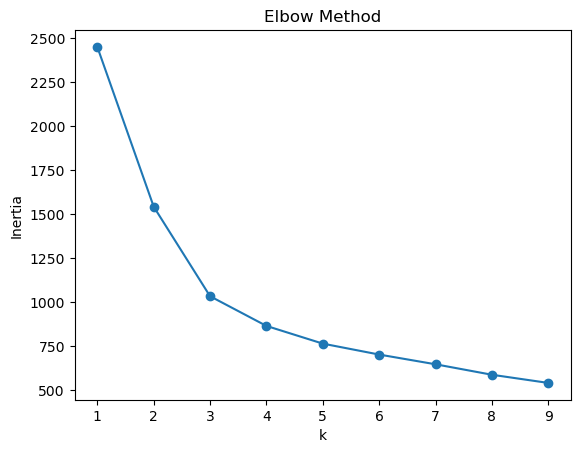

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# use the elbow method to find the optimal number of clusters.
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [28]:
# fit the final KMeans model with k = 3, chosen from the elbow plot
kmeans = KMeans(n_clusters=3, random_state=42)

# assign each college a cluster label and store it back in the dataframe
df['cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\kousa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [29]:
# summarize each cluster by computing the mean of every feature
df.groupby('cluster')[features].mean()

,medianBaseSalary,studentFacultyRatio,percentOfStudentsFinAid,percentOfStudentsGrant,totalStudentPop
cluster,,,,,
0,107810.674157,19.016854,85.033708,76.893258,29941.393258
1,114193.750000,12.049107,96.410714,94.839286,5928.808036
2,139377.272727,9.352273,62.295455,53.397727,13605.852273


In [30]:
# cluster 0: large public universities with moderate salaries and broad financial aid
df[df['cluster'] == 0]['organizationName'].head(10)

5        University of California, Los Angeles
22             University of California, Davis
25                       University of Florida
29            University of California, Irvine
32           University of Washington, Seattle
33    University of Illinois, Urbana-Champaign
34             Georgia Institute of Technology
39        University of Maryland, College Park
42                 University of Texas, Austin
48            University of Wisconsin, Madison
Name: organizationName, dtype: object

In [31]:
# cluster 1: smaller private colleges with high financial aid rates and lower student populations
df[df['cluster'] == 1]['organizationName'].head(10)

74     New Jersey Institute of Technology
91                       Grinnell College
96                University of Rochester
99            Loyola Marymount University
106       Case Western Reserve University
108               University of San Diego
114                     Tulane University
122              Colorado School of Mines
123    CUNY, The City College of New York
129                    Yeshiva University
Name: organizationName, dtype: object

In [32]:
# cluster 2: elite universities with the highest median salaries, low student-faculty ratios, and less reliance on grant aid
df[df['cluster'] == 2]['organizationName'].head(10)

0     Massachusetts Institute of Technology
1                       Stanford University
2        University of California, Berkeley
3                      Princeton University
4                       Columbia University
6                          Williams College
7                           Yale University
8                           Duke University
9                University of Pennsylvania
10                  Northwestern University
Name: organizationName, dtype: object